# Plot IICRsim and IICRinf and get RMSE

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



# ============================================================
## Theme
# ============================================================


In [3]:
def set_paper_theme():
    sns.set_theme(
        style="white",
        context="paper",
        rc={
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
            "font.size": 12,
            "axes.labelsize": 15,
            "axes.titlesize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "legend.title_fontsize": 10,

            "axes.edgecolor": "#333333",
            "axes.linewidth": 0.8,
            "axes.facecolor": "white",
            "figure.facecolor": "white",

            "xtick.color": "#333333",
            "ytick.color": "#333333",
            "axes.labelcolor": "#222222",
            "text.color": "#222222",

            "legend.frameon": True,
            "legend.framealpha": 0.9,
            "legend.edgecolor": "#CCCCCC",

            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


set_paper_theme()


# ============================================================
## Functions
# ============================================================


In [4]:

def rmse_log(iicr_sim, iicr_inf):
    """RMSE first, then log10(RMSE)."""
    iicr_sim = np.asarray(iicr_sim, dtype=float)
    iicr_inf = np.asarray(iicr_inf, dtype=float)

    ok = np.isfinite(iicr_sim) & np.isfinite(iicr_inf)

    rmse = np.sqrt(np.mean((iicr_sim[ok] - iicr_inf[ok]) ** 2))
    log_rmse = np.log10(rmse)

    return rmse, log_rmse



In [5]:

def read_iicr_file(file, labels, inference_col="PSMC_Inference", method="PSMC"):
    file = Path(file)

    df = pd.read_csv(file, sep="\t", dtype=str)
    df.columns = df.columns.str.replace("#", "", regex=False)

    df["row_id"] = df.index

    df["Time"] = df["Time"].str.split()
    df["IICR"] = df["IICR"].str.split()
    df[inference_col] = df[inference_col].str.split()

    df = df.explode(["Time", "IICR", inference_col], ignore_index=True)

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["IICRsim"] = pd.to_numeric(df["IICR"], errors="coerce")
    df["IICRinf"] = pd.to_numeric(df[inference_col], errors="coerce")

    df["IICRsim"] = (
        df.groupby("row_id")["IICRsim"]
        .transform(lambda x: x.interpolate().ffill().bfill())
    )

    df["IICRinf"] = (
        df.groupby("row_id")["IICRinf"]
        .transform(lambda x: x.interpolate().ffill().bfill())
    )

    df["file"] = file.name
    df["label"] = labels[file.name]
    df["method"] = method

    return df[["file", "label", "method", "Time", "IICRsim", "IICRinf"]]




# ============================================================
## Vector PSMC
# ============================================================


In [6]:

directory = Path("/Users/alba/files/2026/structred_smc_IICR/vector_psmc")

files = [
    directory / "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p2_2_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p1_1_1_1_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p24_1_15_2_4_6_psmc.log.out",
]

labels = {
    "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out": "4+25*2+4+6 (default)",
    "gyarados_StSi_s100_p2_2_25_2_4_6_psmc.log.out": "2+2+25*2+4+6",
    "gyarados_StSi_s100_p1_1_1_1_25_2_4_6_psmc.log.out": "1+1+1+1+25*2+4+6",
    "gyarados_StSi_s100_p24_1_15_2_4_6_psmc.log.out": "24*1+15*2+4+6",
}

vector_order = [
    "4+25*2+4+6 (default)",
    "2+2+25*2+4+6",
    "1+1+1+1+25*2+4+6",
    "24*1+15*2+4+6",
]



### Read files



In [7]:


dat = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="PSMC_Inference",
            method="PSMC"
        )
        for f in files
    ],
    ignore_index=True
)

dat = dat[dat["Time"] <= 1e6].copy()


### Plot IICRsim + PSMC curves


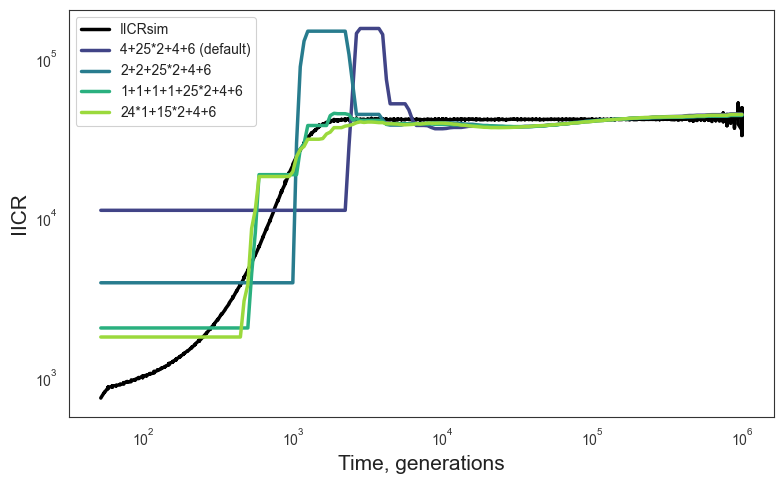

In [8]:
color_iicrsim = "#000000"
# Plot IICRsim + PSMC curves
plt.figure(figsize=(8, 5))


colors = sns.color_palette("viridis", as_cmap=True)(np.linspace(0.20, 0.85, len(vector_order)))

sim = (
    dat[["Time", "IICRsim"]]
    .dropna()
    .drop_duplicates()
    .sort_values("Time")
)

plt.plot(sim["Time"], sim["IICRsim"], color=color_iicrsim, lw=2.5, label="IICRsim")

for label, color in zip(vector_order, colors):
    sub = dat[dat["label"] == label]
    plt.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=label
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time, generations")
plt.ylabel("IICR")
plt.legend()
plt.tight_layout()
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.png", dpi=600)
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.pdf", dpi=600)
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.svg", dpi=600)
plt.show()



### RMSE table


In [9]:


rows = []

for label in vector_order:
    sub = dat[dat["label"] == label]

    rmse, log_rmse = rmse_log(sub["IICRsim"], sub["IICRinf"])

    rows.append({
        "label": label,
        "RMSE": rmse,
        "log10_RMSE": log_rmse
    })

rmse_df = pd.DataFrame(rows)
print(rmse_df)

rmse_df.to_csv(directory / "gyarados_PSMC_vectors_RMSE.csv", index=False)


                  label          RMSE  log10_RMSE
0  4+25*2+4+6 (default)  25853.869220    4.412526
1          2+2+25*2+4+6  30197.986360    4.479978
2      1+1+1+1+25*2+4+6   3051.143179    3.484463
3         24*1+15*2+4+6   3098.001432    3.491082


=====================================================
## Ditto: panmictic scenarios matching the exact same IICR as structured scenarios
====================================================

In [10]:
directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves")

psmc_files = [
    directory / "gyarados_Free_s100_p4_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out",
]

smcpp_files = [
    directory / "gyarados_Free_smcpp.log.out",
    directory / "gyarados_StSi_smcpp.log.out",
]

labels = {
    "gyarados_Free_s100_p4_25_2_4_6_psmc.log.out": "PSMC Panmictic",
    "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out": "PSMC Structured",
    "gyarados_Free_smcpp.log.out": "SMC++ Panmictic",
    "gyarados_StSi_smcpp.log.out": "SMC++ Structured",
}

case_order = ["Panmictic", "Structured"]

### PSMC

In [11]:
dat_psmc = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="PSMC_Inference",
            method="PSMC"
        )
        for f in psmc_files
    ],
    ignore_index=True
)

dat_psmc = dat_psmc[dat_psmc["Time"] <= 1e6].copy()

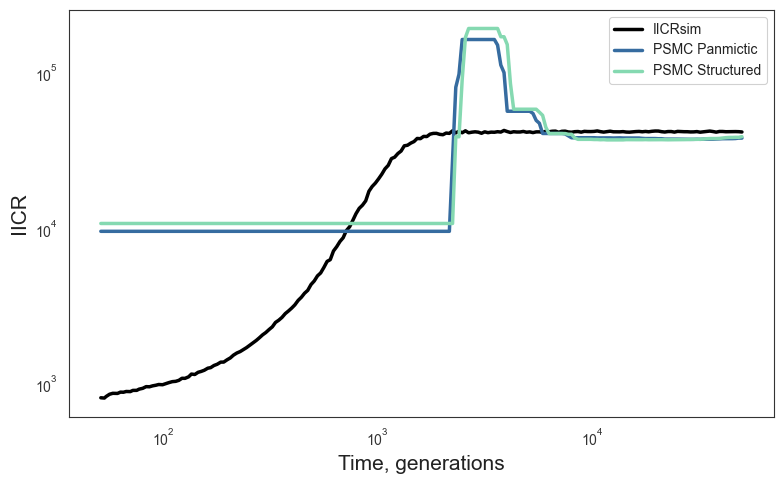

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

color_iicrsim = "#000000"
colors = sns.color_palette("mako", as_cmap=True)(
    np.linspace(0.45, 0.85, len(psmc_files))
)

# IICRsim from one file only
sim = (
    dat_psmc[dat_psmc["file"] == psmc_files[0].name][["Time", "IICRsim"]]
    .dropna()
    .sort_values("Time")
)

ax.plot(
    sim["Time"],
    sim["IICRsim"],
    color=color_iicrsim,
    lw=2.5,
    label="IICRsim"
)

for f, color in zip(psmc_files, colors):
    sub = dat_psmc[dat_psmc["file"] == f.name]

    ax.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=labels[f.name]
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time, generations")
ax.set_ylabel("IICR")
ax.grid(False)
ax.legend()

fig.tight_layout()
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.png", dpi=600)
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.pdf", dpi=600)
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.svg", dpi=600)
plt.show()


### SMC++

In [13]:
dat_smcpp = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="SMCpp_Inference",
            method="SMC++"
        )
        for f in smcpp_files
    ],
    ignore_index=True
)

dat_smcpp = dat_smcpp[dat_smcpp["Time"] <= 1e6].copy()

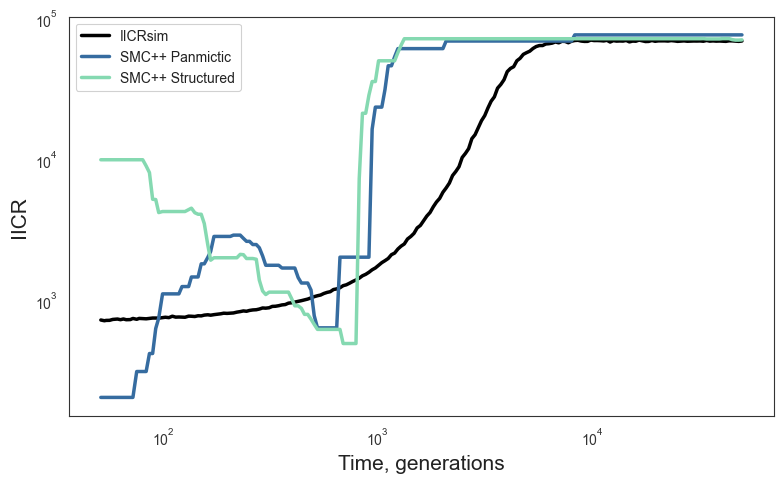

In [14]:
# Plot SMC++ curves

fig, ax = plt.subplots(figsize=(8, 5))

color_iicrsim = "#000000"
colors = sns.color_palette("mako", as_cmap=True)(
    np.linspace(0.45, 0.85, len(smcpp_files))
)

# IICRsim from one file only
sim = (
    dat_smcpp[dat_smcpp["file"] == smcpp_files[0].name][["Time", "IICRsim"]]
    .dropna()
    .sort_values("Time")
)

ax.plot(
    sim["Time"],
    sim["IICRsim"],
    color=color_iicrsim,
    lw=2.5,
    label="IICRsim"
)

for f, color in zip(smcpp_files, colors):
    sub = dat_smcpp[dat_smcpp["file"] == f.name]

    ax.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=labels[f.name]
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time, generations")
ax.set_ylabel("IICR")
ax.grid(False)
ax.legend()

fig.tight_layout()
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.png", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.pdf", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.svg", dpi=600)
plt.show()

                source   d     M
0         Free / ditto   5   1.0
4000  StSi / non-ditto   5   1.0
1400      Free / ditto   5   2.5
5000  StSi / non-ditto   5   2.5
1000      Free / ditto   5   5.0
4200  StSi / non-ditto   5   5.0
800       Free / ditto   5  15.0
5800  StSi / non-ditto   5  15.0
2200      Free / ditto   5  50.0
5600  StSi / non-ditto   5  50.0
200       Free / ditto  10   1.0
4400  StSi / non-ditto  10   1.0
400       Free / ditto  10   2.5
4600  StSi / non-ditto  10   2.5
2000      Free / ditto  10   5.0
6400  StSi / non-ditto  10   5.0
1800      Free / ditto  10  15.0
5200  StSi / non-ditto  10  15.0
3000      Free / ditto  10  50.0
6600  StSi / non-ditto  10  50.0
600       Free / ditto  20   1.0
4800  StSi / non-ditto  20   1.0
1600      Free / ditto  20   2.5
6000  StSi / non-ditto  20   2.5
2600      Free / ditto  20   5.0
7000  StSi / non-ditto  20   5.0
2800      Free / ditto  20  15.0
6800  StSi / non-ditto  20  15.0
3200      Free / ditto  20  50.0
7200  StSi

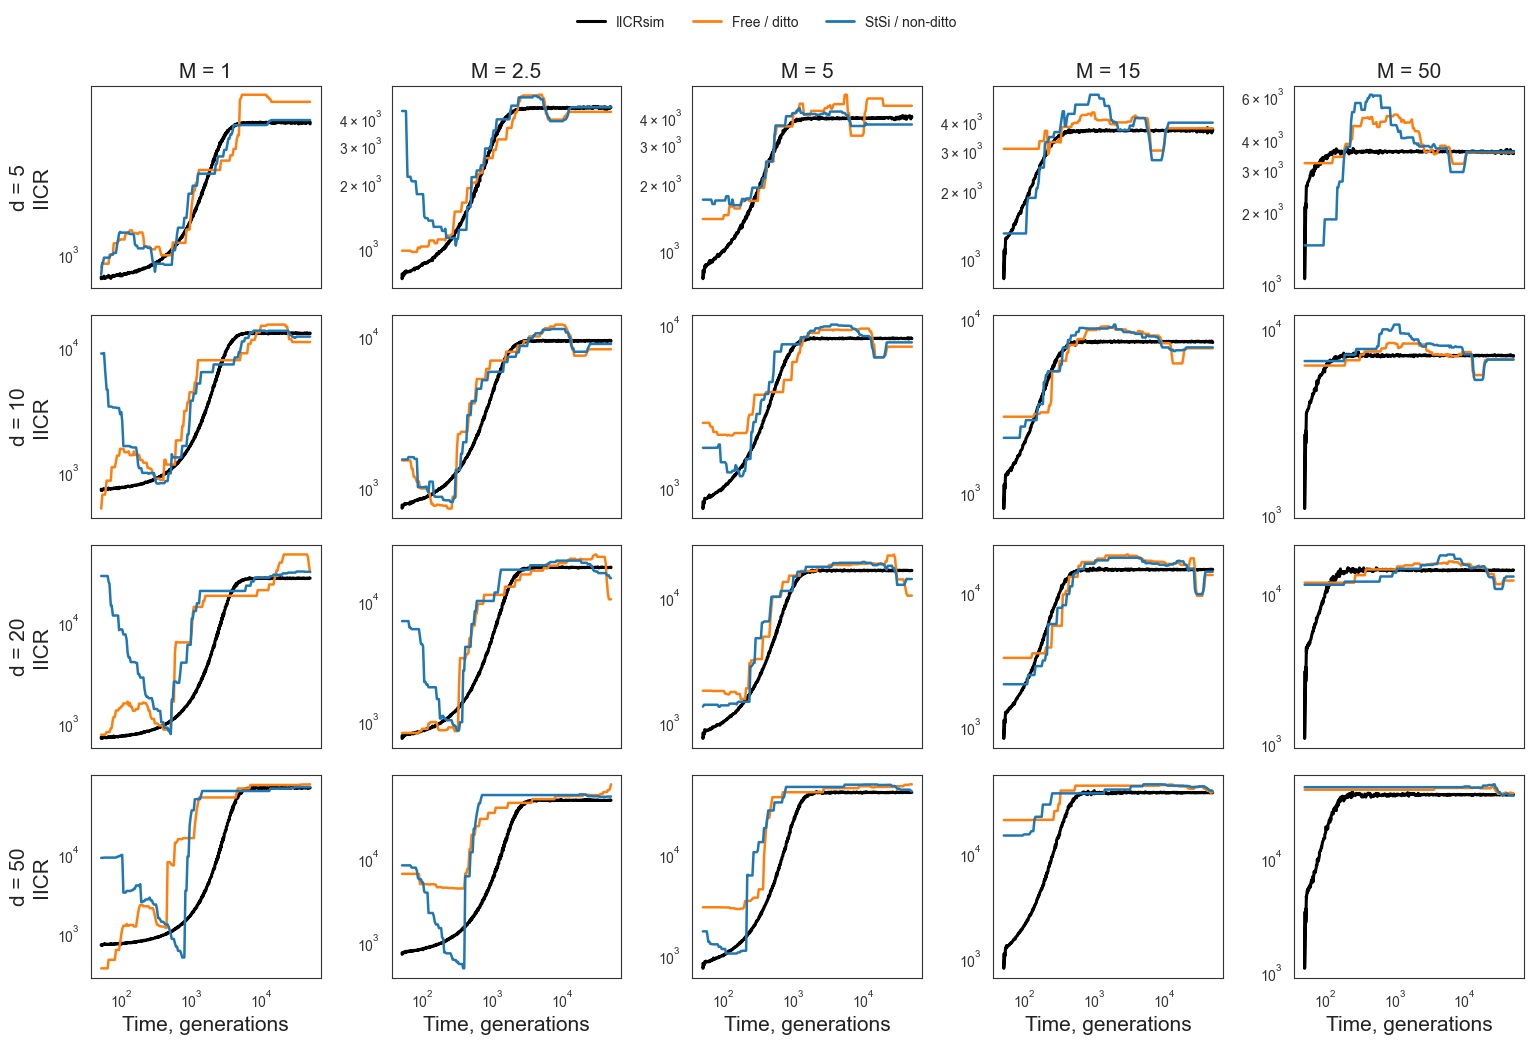

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================================================
# Folder and files
# =====================================================

directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves/all_FIM_smcpp")

files = {
    "Free / ditto": directory / "gyarados_Free_smcpp.log.out",
    "StSi / non-ditto": directory / "gyarados_StSi_smcpp.log.out",
}

N = 1400
rows = []


# =====================================================
# Read both files
# =====================================================

for source, file in files.items():

    with open(file) as f:
        header = f.readline().strip().split("\t")
        header = [h.replace("#", "") for h in header]

        for line in f:
            parts = line.rstrip("\n").split("\t")

            # -------------------------------------------------
            # Case 1: file has a name column
            # Extract d and log10(m) from the name
            # -------------------------------------------------
            if "name" in header:

                name_index = header.index("name")
                name = parts[name_index]

                d = int(re.search(r"_(\d+)I_", name).group(1))

                log10_m = float(
                    re.search(r"_m_(-?\d+(?:\.\d+)?)_", name).group(1)
                )

                m = 10 ** log10_m
                M = 2 * N * m * (d - 1)

                # In these files there may be one extra column before Time,
                # so the safest is to take the last three fields.
                time = np.array(parts[-3].split(), dtype=float)
                iicrsim = np.array(parts[-2].split(), dtype=float)
                iicrinf = np.array(parts[-1].split(), dtype=float)

            # -------------------------------------------------
            # Case 2: file has columns N, d, m directly
            # This is only here in case one file has no name column.
            # -------------------------------------------------
            else:

                d = int(parts[header.index("d")])
                m = float(parts[header.index("m")])
                M = 2 * N * m * (d - 1)

                time = np.array(parts[header.index("Time")].split(), dtype=float)
                iicrsim = np.array(parts[header.index("IICR")].split(), dtype=float)
                iicrinf = np.array(parts[header.index("SMCpp_Inference")].split(), dtype=float)

            # round M to nice labels
            expected_M = np.array([1, 2.5, 5, 15, 50])
            M = expected_M[np.argmin(abs(expected_M - M))]

            n = min(len(time), len(iicrsim), len(iicrinf))

            for k in range(n):
                rows.append({
                    "source": source,
                    "d": d,
                    "M": M,
                    "Time": time[k],
                    "IICRsim": iicrsim[k],
                    "IICRinf": iicrinf[k],
                })


dat = pd.DataFrame(rows)

dat = dat[
    (dat["Time"] > 0) &
    (dat["IICRsim"] > 0) &
    (dat["IICRinf"] > 0)
].copy()

print(
    dat[["source", "d", "M"]]
    .drop_duplicates()
    .sort_values(["d", "M", "source"])
)


# =====================================================
# Panel plot: columns = M, rows = d
# =====================================================

d_values = sorted(dat["d"].unique())
M_values = sorted(dat["M"].unique())

fig, axes = plt.subplots(
    nrows=len(d_values),
    ncols=len(M_values),
    figsize=(3.1 * len(M_values), 2.6 * len(d_values)),
    sharex=True,
    sharey=False
)

if len(d_values) == 1:
    axes = np.array([axes])

if len(M_values) == 1:
    axes = axes.reshape(-1, 1)


for i, d in enumerate(d_values):
    for j, M in enumerate(M_values):

        ax = axes[i, j]

        panel = dat[(dat["d"] == d) & (dat["M"] == M)]

        if panel.empty:
            ax.set_axis_off()
            continue

        # IICRsim once per panel
        sim = (
            panel[["Time", "IICRsim"]]
            .drop_duplicates()
            .sort_values("Time")
        )

        ax.plot(
            sim["Time"],
            sim["IICRsim"],
            color="black",
            lw=2.2
        )

        # Free / ditto inference
        free = (
            panel[panel["source"] == "Free / ditto"]
            .sort_values("Time")
        )

        ax.plot(
            free["Time"],
            free["IICRinf"],
            color="tab:orange",
            lw=1.8
        )

        # StSi / non-ditto inference
        stsi = (
            panel[panel["source"] == "StSi / non-ditto"]
            .sort_values("Time")
        )

        ax.plot(
            stsi["Time"],
            stsi["IICRinf"],
            color="tab:blue",
            lw=1.8
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(False)

        if i == 0:
            ax.set_title(f"M = {M:g}")

        if j == 0:
            ax.set_ylabel(f"d = {d}\nIICR")

        if i == len(d_values) - 1:
            ax.set_xlabel("Time, generations")


# =====================================================
# Legend and save
# =====================================================

legend_elements = [
    Line2D([0], [0], color="black", lw=2.2, label="IICRsim"),
    Line2D([0], [0], color="tab:orange", lw=2.0, label="Free / ditto"),
    Line2D([0], [0], color="tab:blue", lw=2.0, label="StSi / non-ditto"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(directory / "SMCPP_Free_vs_StSi_panel_by_M_and_d.png", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_panel_by_M_and_d.pdf", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_panel_by_M_and_d.svg", dpi=600)

plt.show()

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =====================================================
# Path and files
# =====================================================

directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves/all_FIM_smcpp")

files = {
    "Panmictic": directory / "gyarados_Free_smcpp.log.out",
    "Structured": directory / "gyarados_StSi_smcpp.log.out",
}

N = 1400
expected_M = np.array([1, 2.5, 5, 15, 50])

rows = []


# =====================================================
# Read files
# =====================================================

for source, file in files.items():

    with open(file) as f:
        header = f.readline().strip().split("\t")
        header = [h.replace("#", "") for h in header]

        for line in f:
            parts = line.rstrip("\n").split("\t")

            # ---------------------------------------------
            # If the file has a name column, extract d and m from the name
            # Example:
            # StSI_5I_N-5x1400_..._m_-4.679_...
            # ---------------------------------------------

            if "name" in header:

                name = parts[header.index("name")]

                d = int(re.search(r"_(\d+)I_", name).group(1))

                log10_m = float(
                    re.search(r"_m_(-?\d+(?:\.\d+)?)_", name).group(1)
                )

                m = 10 ** log10_m

                # Take the last three columns because the Free file has one extra column
                # before the vector columns.
                time = np.array(parts[-3].split(), dtype=float)
                iicrsim = np.array(parts[-2].split(), dtype=float)
                iicrinf = np.array(parts[-1].split(), dtype=float)

            # ---------------------------------------------
            # If the file has no name column, use d and m columns directly
            # ---------------------------------------------

            else:

                d = int(parts[header.index("d")])
                m = float(parts[header.index("m")])

                time = np.array(parts[header.index("Time")].split(), dtype=float)
                iicrsim = np.array(parts[header.index("IICR")].split(), dtype=float)
                iicrinf = np.array(parts[header.index("SMCpp_Inference")].split(), dtype=float)

            # ---------------------------------------------
            # Calculate M
            # ---------------------------------------------

            M_raw = 2 * N * m * (d - 1)

            # Snap to expected values: 1, 2.5, 5, 15, 50
            M = expected_M[np.argmin(abs(expected_M - M_raw))]

            n = min(len(time), len(iicrsim), len(iicrinf))

            for k in range(n):
                rows.append({
                    "source": source,
                    "d": d,
                    "M": M,
                    "Time": time[k],
                    "IICRsim": iicrsim[k],
                    "IICRinf": iicrinf[k],
                })


# =====================================================
# Make dataframe
# =====================================================

dat = pd.DataFrame(rows)

dat = dat[
    (dat["Time"] > 0) &
    (dat["IICRsim"] > 0) &
    (dat["IICRinf"] > 0)
].copy()

dat["d"] = dat["d"].astype(int)

print("Scenarios found:")
print(
    dat[["source", "d", "M"]]
    .drop_duplicates()
    .sort_values(["d", "M", "source"])
    .to_string(index=False)
)


# =====================================================
# Panel plot: rows = d, columns = M
# =====================================================

d_values = sorted(dat["d"].unique())
M_values = sorted(dat["M"].unique())

fig, axes = plt.subplots(
    nrows=len(d_values),
    ncols=len(M_values),
    figsize=(3.1 * len(M_values), 2.6 * len(d_values)),
    sharex=True,
    sharey=False
)

if len(d_values) == 1 and len(M_values) == 1:
    axes = np.array([[axes]])
elif len(d_values) == 1:
    axes = axes.reshape(1, -1)
elif len(M_values) == 1:
    axes = axes.reshape(-1, 1)


for i, d in enumerate(d_values):
    for j, M in enumerate(M_values):

        ax = axes[i, j]

        panel = dat[
            (dat["d"] == d) &
            (dat["M"] == M)
        ]

        if panel.empty:
            ax.set_axis_off()
            continue

        # Plot IICRsim once per panel.
        # Use the panmictic curve if present; otherwise use whatever exists.
        sim = panel[panel["source"] == "Panmictic"]

        if sim.empty:
            sim = panel

        sim = sim.sort_values("Time")

        ax.plot(
            sim["Time"],
            sim["IICRsim"],
            color="black",
            lw=2.2
        )

        # Panmictic inference
        pan = panel[panel["source"] == "Panmictic"].sort_values("Time")

        if not pan.empty:
            ax.plot(
                pan["Time"],
                pan["IICRinf"],
                color="tab:orange",
                lw=1.8
            )

        # Structured inference
        st = panel[panel["source"] == "Structured"].sort_values("Time")

        if not st.empty:
            ax.plot(
                st["Time"],
                st["IICRinf"],
                color="tab:blue",
                lw=1.8
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(False)

        if i == 0:
            ax.set_title(f"M = {M:g}")

        if j == 0:
            ax.set_ylabel(f"d = {d}\nIICR")

        if i == len(d_values) - 1:
            ax.set_xlabel("Time, generations")


legend_elements = [
    Line2D([0], [0], color="black", lw=2.2, label="IICRsim"),
    Line2D([0], [0], color="tab:orange", lw=2.0, label="Panmictic"),
    Line2D([0], [0], color="tab:blue", lw=2.0, label="Structured"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.png", dpi=600)
fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.pdf", dpi=600)
fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.svg", dpi=600)

plt.show()


# =====================================================
# RMSE table
# =====================================================

rmse_rows = []

for d in d_values:
    for M in M_values:

        row = {
            "d": d,
            "M": M,
            "log10_RMSE_structured": np.nan,
            "log10_RMSE_panmictic": np.nan,
        }

        # Structured RMSE
        st = dat[
            (dat["source"] == "Structured") &
            (dat["d"] == d) &
            (dat["M"] == M)
        ]

        if not st.empty:
            iicr_sim = st["IICRsim"].to_numpy(dtype=float)
            iicr_inf = st["IICRinf"].to_numpy(dtype=float)

            ok = np.isfinite(iicr_sim) & np.isfinite(iicr_inf)

            rmse = np.sqrt(np.mean((iicr_sim[ok] - iicr_inf[ok]) ** 2))
            row["log10_RMSE_structured"] = np.log10(rmse)

        # Panmictic RMSE
        pan = dat[
            (dat["source"] == "Panmictic") &
            (dat["d"] == d) &
            (dat["M"] == M)
        ]

        if not pan.empty:
            iicr_sim = pan["IICRsim"].to_numpy(dtype=float)
            iicr_inf = pan["IICRinf"].to_numpy(dtype=float)

            ok = np.isfinite(iicr_sim) & np.isfinite(iicr_inf)

            rmse = np.sqrt(np.mean((iicr_sim[ok] - iicr_inf[ok]) ** 2))
            row["log10_RMSE_panmictic"] = np.log10(rmse)

        rmse_rows.append(row)


rmse_table = pd.DataFrame(rmse_rows)

rmse_table = rmse_table[
    [
        "d",
        "M",
        "log10_RMSE_structured",
        "log10_RMSE_panmictic",
    ]
].sort_values(["d", "M"]).reset_index(drop=True)

rmse_table.to_csv(
    directory / "SMCPP_log10_RMSE_structured_vs_panmictic.csv",
    index=False
)

rmse_table

              source   d     M          RMSE  log10_RMSE
0       Free / ditto   5   1.0   1463.769774    3.165473
20  StSi / non-ditto   5   1.0    393.971238    2.595465
1       Free / ditto   5   2.5    355.144679    2.550405
21  StSi / non-ditto   5   2.5    720.004782    2.857335
2       Free / ditto   5   5.0    508.475040    2.706270
22  StSi / non-ditto   5   5.0    380.857181    2.580762
3       Free / ditto   5  15.0    686.476821    2.836626
23  StSi / non-ditto   5  15.0    653.650668    2.815346
4       Free / ditto   5  50.0    706.317002    2.849000
24  StSi / non-ditto   5  50.0   1162.362154    3.065341
5       Free / ditto  10   1.0   2212.989817    3.344979
25  StSi / non-ditto  10   1.0   2052.392886    3.312261
6       Free / ditto  10   2.5   1425.575279    3.153990
26  StSi / non-ditto  10   2.5   1102.957324    3.042559
7       Free / ditto  10   5.0   1153.977193    3.062197
27  StSi / non-ditto  10   5.0   1082.475872    3.034418
8       Free / ditto  10  15.0 

Found 10 non-ditto files
Found 0 ditto files


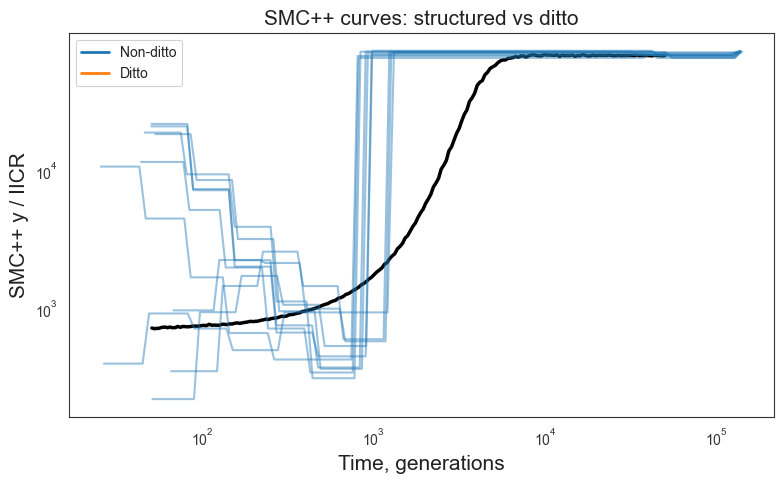

In [17]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# folder containing the CSV files
directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves/st_smcpp2")

# restrict to this simulation
pattern = (
    "StSI_50I_N-50x1400_sam-49x0-1x20_m_-5.1374_size-5x100000000_mu_1.0E-08_gr_0_no_events*.csv"
)

files = sorted(directory.glob(pattern))

# split files
ditto_files = [f for f in files if "ditto" in f.name]
non_ditto_files = [f for f in files if "ditto" not in f.name]

print(f"Found {len(non_ditto_files)} non-ditto files")
print(f"Found {len(ditto_files)} ditto files")

def rep_number(path):
    """
    Extract the final individual index:
    ..._ind_G_1_10_start_0.csv -> 10
    ..._ind_G_1_3_start_0.csv  -> 3
    """
    m = re.search(r"_ind_G_1_(\d+)_start", path.name)
    return int(m.group(1)) if m else 9999

non_ditto_files = sorted(non_ditto_files, key=rep_number)
ditto_files = sorted(ditto_files, key=rep_number)

def read_curve(path):
    df = pd.read_csv(path)

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    df = df.dropna(subset=["x", "y"])
    df = df[df["x"] > 0].copy()

    return df

plt.figure(figsize=(8, 5))

plt.plot(
    sim["Time"],
    sim["IICRsim"],
    color="black",
    lw=2.5,
    label="IICRsim"
)

# non-ditto curves
for f in non_ditto_files:
    df = read_curve(f)
    plt.plot(
        df["x"],
        df["y"],
        color="tab:blue",
        alpha=0.45,
        lw=1.5
    )

# ditto curves
for f in ditto_files:
    df = read_curve(f)
    plt.plot(
        df["x"],
        df["y"],
        color="tab:orange",
        alpha=0.45,
        lw=1.5
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Time, generations")
plt.ylabel("SMC++ y / IICR")
plt.title("SMC++ curves: structured vs ditto")

legend_elements = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Non-ditto"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Ditto"),
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [11]:
df

,label,x,y,plot_type,plot_num
1,G_1,0.100378,749.417958,path,0
2,G_1,0.115958,761.964469,path,0
3,G_1,0.133956,771.129628,path,0
4,G_1,0.154748,775.484919,path,0
5,G_1,0.178767,775.472668,path,0
...,...,...,...,...,...
96,G_1,90062.870456,95554.723236,path,0
97,G_1,104041.828572,85355.984353,path,0
98,G_1,120190.507339,55775.006592,path,0
99,G_1,138845.676327,24267.486687,path,0


Scenarios found:
    source  d    M
 Panmictic  5  1.0
Structured  5  1.0
 Panmictic  5  2.5
Structured  5  2.5
 Panmictic  5  5.0
Structured  5  5.0
 Panmictic  5 15.0
Structured  5 15.0
 Panmictic  5 50.0
Structured  5 50.0
 Panmictic 10  1.0
Structured 10  1.0
 Panmictic 10  2.5
Structured 10  2.5
 Panmictic 10  5.0
Structured 10  5.0
 Panmictic 10 15.0
Structured 10 15.0
 Panmictic 10 50.0
Structured 10 50.0
 Panmictic 20  1.0
Structured 20  1.0
 Panmictic 20  2.5
Structured 20  2.5
 Panmictic 20  5.0
Structured 20  5.0
 Panmictic 20 15.0
Structured 20 15.0
 Panmictic 20 50.0
Structured 20 50.0
 Panmictic 50  1.0
Structured 50  1.0
 Panmictic 50  2.5
Structured 50  2.5
 Panmictic 50  5.0
Structured 50  5.0
 Panmictic 50 15.0
Structured 50 15.0
 Panmictic 50 50.0
Structured 50 50.0


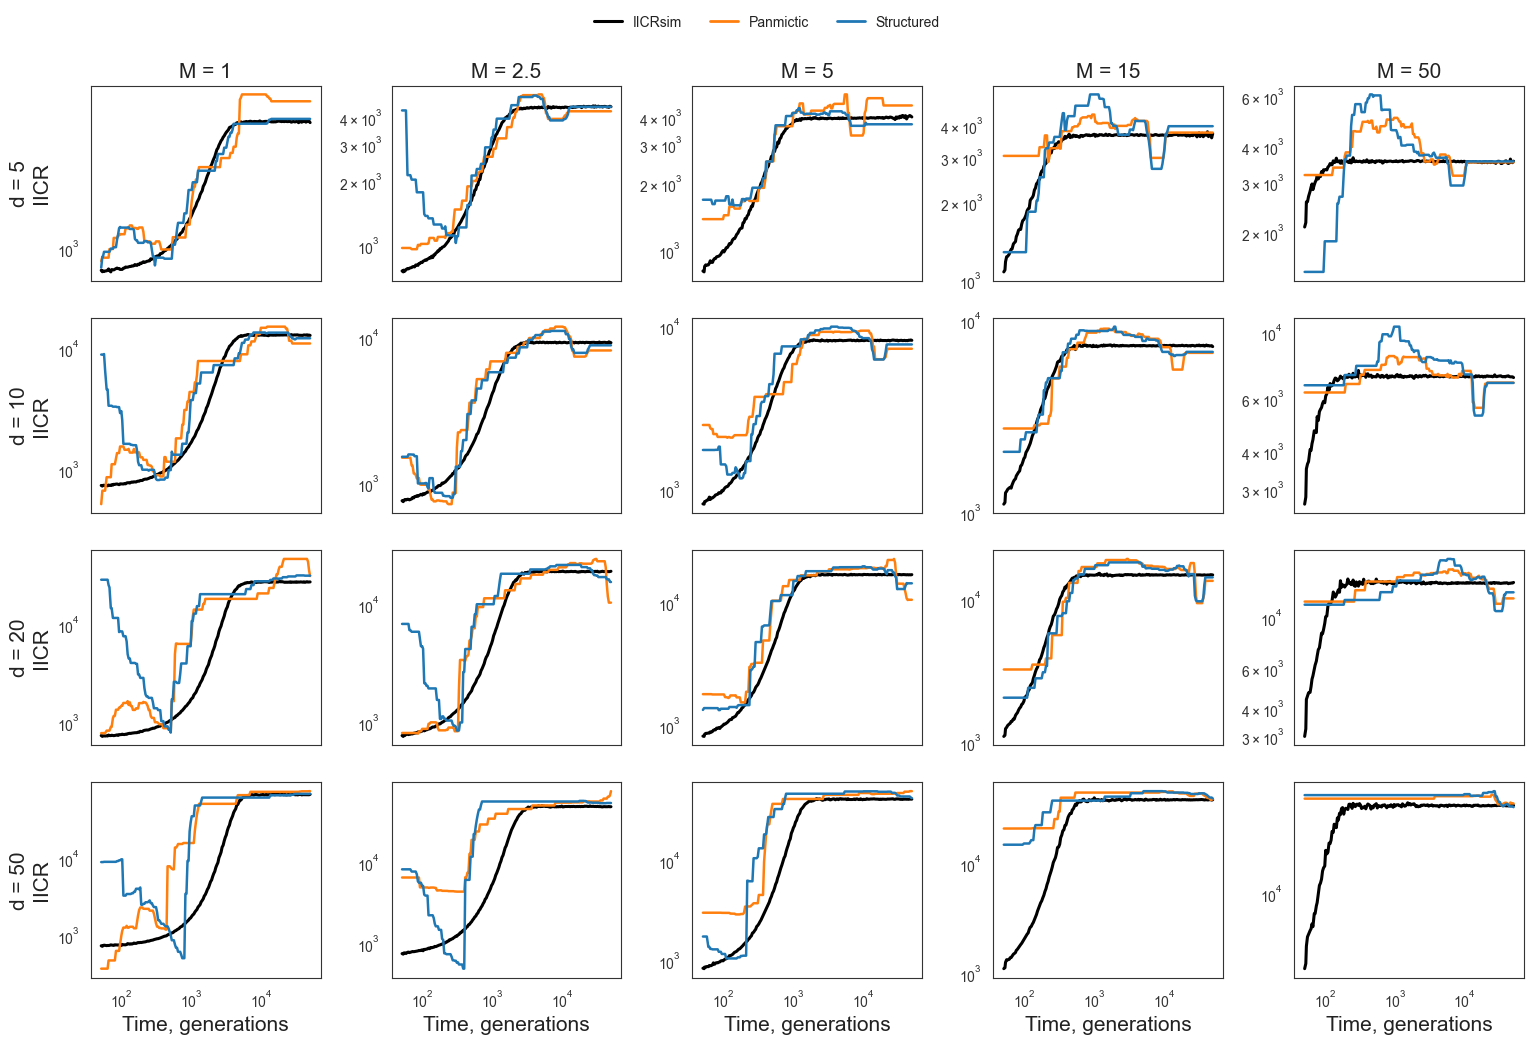

,d,M,log10_RMSE_structured,log10_RMSE_panmictic,SMCpp_bias_structured,SMCpp_bias_panmictic,SMCpp_relative_intensity_structured,SMCpp_relative_intensity_panmictic,SMCpp_present_time_structured,SMCpp_present_time_panmictic,SMCpp_min_time_structured,SMCpp_min_time_panmictic,SMCpp_present_IICR_structured,SMCpp_present_IICR_panmictic,SMCpp_min_IICR_structured,SMCpp_min_IICR_panmictic
0,5,1.0,2.595465,3.165473,False,False,0.000000,0.000000,51.0,51.0,51.0,51.0,759.990023,832.452578,759.990023,832.452578
1,5,2.5,2.857335,2.550405,True,False,0.760848,0.013017,51.0,51.0,300.0,70.0,4309.785127,976.884038,1030.693953,964.167525
2,5,5.0,2.580762,2.706270,False,False,0.056200,0.000000,51.0,51.0,140.0,51.0,1691.969152,1382.975482,1596.879667,1382.975482
3,5,15.0,2.815346,2.836626,False,False,0.000000,0.053741,51.0,51.0,51.0,220.0,1285.999870,3035.946019,1285.999870,2872.791661
4,5,50.0,3.065341,2.849000,False,False,0.000000,0.005285,51.0,51.0,51.0,6744.0,1444.413090,3175.106130,1444.413090,3158.324232
5,10,1.0,3.312261,3.344979,True,False,0.908973,0.000000,51.0,51.0,322.0,51.0,8900.690279,511.028445,810.202380,511.028445
6,10,2.5,3.042559,3.153990,False,False,0.476984,0.520794,51.0,51.0,252.0,236.0,1520.041060,1498.687561,795.006394,718.180753
7,10,5.0,3.034418,3.062197,False,False,0.329434,0.164270,51.0,51.0,172.0,114.0,1747.888659,2484.395714,1172.074101,2076.284214
8,10,15.0,2.941296,3.011945,False,False,0.000000,0.000000,51.0,51.0,51.0,51.0,2062.537449,2727.352208,2062.537449,2727.352208
9,10,50.0,3.170155,2.958107,False,False,0.207525,0.110980,51.0,51.0,13930.0,13930.0,6648.822908,6289.644685,5269.027066,5591.620504


In [29]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =====================================================
# Folder and files
# =====================================================

directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves/all_FIM_smcpp")

free_file = directory / "gyarados_Free_smcpp.log.out"
stsi_file = directory / "gyarados_StSi_smcpp.log.out"

N_FIXED = 1400
expected_M = np.array([1, 2.5, 5, 15, 50])

rows = []


# =====================================================
# Read Free / panmictic file
# Header:
# #ID #d #n_mm #events #gr #name #Repetition #Time #IICR #SMCpp_Inference
#
# But the rows have one extra column before Time.
# So vectors are taken as the last three columns.
# =====================================================

with open(free_file) as f:
    header = f.readline()

    for line in f:
        parts = line.rstrip("\n").split("\t")

        name = parts[5]

        d = int(re.search(r"_(\d+)I_", name).group(1))
        log10_m = float(re.search(r"_m_(-?\d+(?:\.\d+)?)_", name).group(1))
        m = 10 ** log10_m

        M_raw = 2 * N_FIXED * m * (d - 1)
        M = expected_M[np.argmin(np.abs(expected_M - M_raw))]

        time = np.array(parts[-3].split(), dtype=float)
        iicrsim = np.array(parts[-2].split(), dtype=float)
        iicrinf = np.array(parts[-1].split(), dtype=float)

        n = min(len(time), len(iicrsim), len(iicrinf))

        for k in range(n):
            rows.append({
                "source": "Panmictic",
                "d": d,
                "M": M,
                "M_raw": M_raw,
                "Time": time[k],
                "IICRsim": iicrsim[k],
                "IICRinf": iicrinf[k],
            })


# =====================================================
# Read StSi / structured file
# Header:
# #ID #N #d #m #Repetition #Time #IICR #SMCpp_Inference
# =====================================================

with open(stsi_file) as f:
    header = f.readline()

    for line in f:
        parts = line.rstrip("\n").split("\t")

        d = int(parts[2])
        m = float(parts[3])

        M_raw = 2 * N_FIXED * m * (d - 1)
        M = expected_M[np.argmin(np.abs(expected_M - M_raw))]

        time = np.array(parts[5].split(), dtype=float)
        iicrsim = np.array(parts[6].split(), dtype=float)
        iicrinf = np.array(parts[7].split(), dtype=float)

        n = min(len(time), len(iicrsim), len(iicrinf))

        for k in range(n):
            rows.append({
                "source": "Structured",
                "d": d,
                "M": M,
                "M_raw": M_raw,
                "Time": time[k],
                "IICRsim": iicrsim[k],
                "IICRinf": iicrinf[k],
            })


# =====================================================
# Main dataframe
# =====================================================

dat = pd.DataFrame(rows)

dat = dat[
    (dat["Time"] > 0) &
    (dat["IICRsim"] > 0) &
    (dat["IICRinf"] > 0)
].copy()

dat["d"] = dat["d"].astype(int)

print("Scenarios found:")
print(
    dat[["source", "d", "M"]]
    .drop_duplicates()
    .sort_values(["d", "M", "source"])
    .to_string(index=False)
)


# =====================================================
# Panel plot: rows = d, columns = M
# =====================================================

d_values = sorted(dat["d"].unique())
M_values = sorted(dat["M"].unique())

fig, axes = plt.subplots(
    nrows=len(d_values),
    ncols=len(M_values),
    figsize=(3.1 * len(M_values), 2.6 * len(d_values)),
    sharex=True,
    sharey=False
)

if len(d_values) == 1 and len(M_values) == 1:
    axes = np.array([[axes]])
elif len(d_values) == 1:
    axes = axes.reshape(1, -1)
elif len(M_values) == 1:
    axes = axes.reshape(-1, 1)


for i, d in enumerate(d_values):
    for j, M in enumerate(M_values):

        ax = axes[i, j]

        panel = dat[
            (dat["d"] == d) &
            (dat["M"] == M)
        ]

        if panel.empty:
            ax.set_axis_off()
            continue

        # IICRsim once per panel
        sim = panel[panel["source"] == "Panmictic"]

        if sim.empty:
            sim = panel

        sim = sim.sort_values("Time")

        ax.plot(
            sim["Time"],
            sim["IICRsim"],
            color="black",
            lw=2.2
        )

        # Panmictic inference
        pan = panel[panel["source"] == "Panmictic"].sort_values("Time")

        if not pan.empty:
            ax.plot(
                pan["Time"],
                pan["IICRinf"],
                color="tab:orange",
                lw=1.8
            )

        # Structured inference
        st = panel[panel["source"] == "Structured"].sort_values("Time")

        if not st.empty:
            ax.plot(
                st["Time"],
                st["IICRinf"],
                color="tab:blue",
                lw=1.8
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(False)

        if i == 0:
            ax.set_title(f"M = {M:g}")

        if j == 0:
            ax.set_ylabel(f"d = {d}\nIICR")

        if i == len(d_values) - 1:
            ax.set_xlabel("Time, generations")


legend_elements = [
    Line2D([0], [0], color="black", lw=2.2, label="IICRsim"),
    Line2D([0], [0], color="tab:orange", lw=2.0, label="Panmictic"),
    Line2D([0], [0], color="tab:blue", lw=2.0, label="Structured"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.png", dpi=600)
fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.pdf", dpi=600)
fig.savefig(directory / "SMCPP_panmictic_vs_structured_panel_by_M_and_d.svg", dpi=600)

plt.show()


# =====================================================
# RMSE and SMC++ bias table
# =====================================================
#
# SMC++ bias definition used here:
#
# Artificial recent recovery is present when the inferred SMC++ curve
# rises from its minimum value to the most recent time point.
#
# relative_intensity = (IICR_present - min_IICR) / IICR_present
#
# bias_present = relative_intensity > 0.5
#
# The most recent time point is taken as min(Time), because in these
# files it is 51 generations, not exactly 50.
# =====================================================

summary_rows = []

for d in d_values:
    for M in M_values:

        row = {
            "d": d,
            "M": M,

            "log10_RMSE_structured": np.nan,
            "log10_RMSE_panmictic": np.nan,

            "SMCpp_bias_structured": np.nan,
            "SMCpp_bias_panmictic": np.nan,

            "SMCpp_relative_intensity_structured": np.nan,
            "SMCpp_relative_intensity_panmictic": np.nan,

            "SMCpp_present_time_structured": np.nan,
            "SMCpp_present_time_panmictic": np.nan,

            "SMCpp_min_time_structured": np.nan,
            "SMCpp_min_time_panmictic": np.nan,

            "SMCpp_present_IICR_structured": np.nan,
            "SMCpp_present_IICR_panmictic": np.nan,

            "SMCpp_min_IICR_structured": np.nan,
            "SMCpp_min_IICR_panmictic": np.nan,
        }

        for source in ["Structured", "Panmictic"]:

            sub = dat[
                (dat["source"] == source) &
                (dat["d"] == d) &
                (dat["M"] == M)
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("Time")

            suffix = "structured" if source == "Structured" else "panmictic"

            # RMSE
            iicr_sim = sub["IICRsim"].to_numpy(dtype=float)
            iicr_inf = sub["IICRinf"].to_numpy(dtype=float)

            ok = np.isfinite(iicr_sim) & np.isfinite(iicr_inf)

            rmse = np.sqrt(np.mean((iicr_sim[ok] - iicr_inf[ok]) ** 2))

            row[f"log10_RMSE_{suffix}"] = np.log10(rmse)

            # SMC++ bias
            present_index = sub["Time"].idxmin()
            present_time = sub.loc[present_index, "Time"]
            present_iicr = sub.loc[present_index, "IICRinf"]

            min_index = sub["IICRinf"].idxmin()
            min_time = sub.loc[min_index, "Time"]
            min_iicr = sub.loc[min_index, "IICRinf"]

            relative_intensity = (present_iicr - min_iicr) / present_iicr
            bias_present = relative_intensity > 0.53

            row[f"SMCpp_bias_{suffix}"] = bool(bias_present)
            row[f"SMCpp_relative_intensity_{suffix}"] = relative_intensity
            row[f"SMCpp_present_time_{suffix}"] = present_time
            row[f"SMCpp_min_time_{suffix}"] = min_time
            row[f"SMCpp_present_IICR_{suffix}"] = present_iicr
            row[f"SMCpp_min_IICR_{suffix}"] = min_iicr

        summary_rows.append(row)


summary_table = pd.DataFrame(summary_rows)

summary_table = summary_table[
    [
        "d",
        "M",

        "log10_RMSE_structured",
        "log10_RMSE_panmictic",

        "SMCpp_bias_structured",
        "SMCpp_bias_panmictic",

        "SMCpp_relative_intensity_structured",
        "SMCpp_relative_intensity_panmictic",

        "SMCpp_present_time_structured",
        "SMCpp_present_time_panmictic",

        "SMCpp_min_time_structured",
        "SMCpp_min_time_panmictic",

        "SMCpp_present_IICR_structured",
        "SMCpp_present_IICR_panmictic",

        "SMCpp_min_IICR_structured",
        "SMCpp_min_IICR_panmictic",
    ]
].sort_values(["d", "M"]).reset_index(drop=True)

summary_table.to_csv(
    directory / "SMCPP_RMSE_and_bias_structured_vs_panmictic.csv",
    index=False
)

summary_table

In [30]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

# =====================================================
# Paired Wilcoxon signed-rank test
# Structured artifact intensity - Panmictic / ditto artifact intensity
# =====================================================

wilcox_df = summary_table[
    [
        "d",
        "M",
        "SMCpp_relative_intensity_structured",
        "SMCpp_relative_intensity_panmictic",
    ]
].copy()

wilcox_df = wilcox_df.rename(
    columns={
        "SMCpp_relative_intensity_structured": "artifact_intensity_structured",
        "SMCpp_relative_intensity_panmictic": "artifact_intensity_ditto",
    }
)

wilcox_df = wilcox_df.dropna(
    subset=[
        "artifact_intensity_structured",
        "artifact_intensity_ditto",
    ]
).copy()

wilcox_df["artifact_intensity_difference"] = (
    wilcox_df["artifact_intensity_structured"] -
    wilcox_df["artifact_intensity_ditto"]
)

# Wilcoxon paired signed-rank test
# H0: median paired difference = 0
# two-sided test by default
test = wilcoxon(
    wilcox_df["artifact_intensity_structured"],
    wilcox_df["artifact_intensity_ditto"],
    alternative="two-sided",
    zero_method="wilcox"
)

print("Paired Wilcoxon signed-rank test")
print("--------------------------------")
print(f"Number of matched pairs: {len(wilcox_df)}")
print(f"Mean difference: {wilcox_df['artifact_intensity_difference'].mean()}")
print(f"Median difference: {wilcox_df['artifact_intensity_difference'].median()}")
print(f"Wilcoxon statistic: {test.statistic}")
print(f"p-value: {test.pvalue}")

wilcox_df

Paired Wilcoxon signed-rank test
--------------------------------
Number of matched pairs: 20
Mean difference: 0.2792833329970644
Median difference: 0.05923196367066598
Wilcoxon statistic: 16.0
p-value: 0.007169734292803207


,d,M,artifact_intensity_structured,artifact_intensity_ditto,artifact_intensity_difference
0,5,1.0,0.000000,0.000000,0.000000
1,5,2.5,0.760848,0.013017,0.747831
2,5,5.0,0.056200,0.000000,0.056200
3,5,15.0,0.000000,0.053741,-0.053741
4,5,50.0,0.000000,0.005285,-0.005285
5,10,1.0,0.908973,0.000000,0.908973
6,10,2.5,0.476984,0.520794,-0.043810
7,10,5.0,0.329434,0.164270,0.165164
8,10,15.0,0.000000,0.000000,0.000000
9,10,50.0,0.207525,0.110980,0.096545


## SFS

In [35]:
from pathlib import Path
import re
import numpy as np
import pandas as pd


# =====================================================
# Folder
# =====================================================

directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves/all_FIM_smcpp")

N_FIXED = 1400
expected_M = np.array([1, 2.5, 5, 15, 50])

sample_size = 20
max_minor_count = 10

rows = []


# =====================================================
# Read all SFS files
# =====================================================

sfs_files = sorted(directory.glob("*_sfs.tsv"))

print(f"Found {len(sfs_files)} SFS files")


for sfs_file in sfs_files:

    filename = sfs_file.name
    base = filename.replace("_sfs.tsv", "")

    source = "Panmictic" if "ditto" in filename else "Structured"

    # -------------------------------------------------
    # Parameters from file name
    # -------------------------------------------------

    d = int(re.search(r"_(\d+)I_", filename).group(1))

    log10_m = float(
        re.search(r"_m_(-?\d+(?:\.\d+)?)_", filename).group(1)
    )

    m = 10 ** log10_m

    M_raw = 2 * N_FIXED * m * (d - 1)
    M = expected_M[np.argmin(np.abs(expected_M - M_raw))]

    rep_match = re.search(r"_rep(\d+)", filename)
    rep = int(rep_match.group(1)) if rep_match else 1

    # -------------------------------------------------
    # Matching stats file
    # Expected name: same prefix, ending in _stats.tsv
    # -------------------------------------------------

    stats_file = directory / f"{base}_stats.tsv"

    if not stats_file.exists():
        stats_matches = sorted(directory.glob(base + "*stat*"))
        if len(stats_matches) == 0:
            print(f"WARNING: no stats file found for {filename}")
            continue
        stats_file = stats_matches[0]

    # -------------------------------------------------
    # Read S from stats file
    # -------------------------------------------------

    stats = pd.read_csv(stats_file, sep="\t")
    stats.columns = stats.columns.str.replace("#", "", regex=False)

    if "S" not in stats.columns:
        print(f"WARNING: no S column in {stats_file.name}")
        continue

    S_total = int(float(stats.loc[0, "S"]))

    # -------------------------------------------------
    # Read SFS counts
    # Your file has counts for 2..10.
    # Singleton is reconstructed as:
    #
    # singleton = S - sum(counts from 2 to 10)
    # -------------------------------------------------

    sfs = pd.read_csv(sfs_file, sep="\t")

    counts_row = sfs[sfs["Type"] == "Counts"]

    if counts_row.empty:
        print(f"WARNING: no Counts row in {filename}")
        continue

    counts_row = counts_row.iloc[0].drop("Type")

    counts = {}

    for i in range(2, max_minor_count + 1):
        counts[i] = float(counts_row[str(i)])

    singleton_count = S_total - sum(counts[i] for i in range(2, max_minor_count + 1))

    counts[1] = singleton_count

    if singleton_count < 0:
        print(f"WARNING: negative singleton count in {filename}: {singleton_count}")

    # Check that reconstructed SFS sums back to S
    reconstructed_S = sum(counts[i] for i in range(1, max_minor_count + 1))

    if not np.isclose(reconstructed_S, S_total):
        print(f"WARNING: reconstructed S does not match S in {filename}")

    # -------------------------------------------------
    # Raw non-transformed SFS proportions
    # -------------------------------------------------

    raw_prop = {}

    for i in range(1, max_minor_count + 1):
        raw_prop[i] = counts[i] / S_total

    # -------------------------------------------------
    # Folded Lapierre-style transformation
    #
    # For folded SFS with 20 haploid chromosomes:
    #
    # i = 1..9:
    # transformed_i = count_i * i * (20 - i) / 20
    #
    # i = 10:
    # transformed_10 = count_10 * 10
    #
    # Then normalize by the sum.
    # -------------------------------------------------

    transformed = {}

    for i in range(1, max_minor_count + 1):

        if i < max_minor_count:
            transformed[i] = counts[i] * i * (sample_size - i) / sample_size
        else:
            transformed[i] = counts[i] * max_minor_count

    transformed_sum = sum(transformed.values())

    lapierre = {}

    for i in range(1, max_minor_count + 1):
        lapierre[i] = transformed[i] / transformed_sum

    # -------------------------------------------------
    # Store one row per SFS file
    # -------------------------------------------------

    row = {
        "source": source,
        "file": filename,
        "stats_file": stats_file.name,
        "rep": rep,
        "d": d,
        "M": M,
        "M_raw": M_raw,
        "S": S_total,
        "singleton_count": singleton_count,
        "sum_counts_2_to_10": sum(counts[i] for i in range(2, max_minor_count + 1)),
        "reconstructed_S": reconstructed_S,
    }

    for i in range(1, max_minor_count + 1):
        row[f"count_{i}"] = counts[i]
        row[f"raw_prop_{i}"] = raw_prop[i]
        row[f"lapierre_{i}"] = lapierre[i]

    rows.append(row)


sfs_dat = pd.DataFrame(rows)

print("\nFiles read:")
print(
    sfs_dat[
        [
            "source",
            "rep",
            "d",
            "M",
            "S",
            "singleton_count",
            "sum_counts_2_to_10",
            "file",
        ]
    ]
    .sort_values(["d", "M", "source"])
    .to_string(index=False)
)


# =====================================================
# Pair structured and panmictic / ditto files
# =====================================================

structured = sfs_dat[sfs_dat["source"] == "Structured"].copy()
ditto = sfs_dat[sfs_dat["source"] == "Panmictic"].copy()

pairs = structured.merge(
    ditto,
    on=["rep", "d", "M"],
    suffixes=("_structured", "_ditto")
)

print(f"\nMatched pairs: {len(pairs)}")


# =====================================================
# Final comparison table
# =====================================================

table_rows = []

ton_names = {
    1: "singleton",
    2: "doubleton",
    3: "tripleton",
    4: "quadrupleton",
    5: "5ton",
    6: "6ton",
    7: "7ton",
    8: "8ton",
    9: "9ton",
    10: "10ton",
}


for _, pair in pairs.iterrows():

    row = {
        "rep": pair["rep"],
        "d": pair["d"],
        "M": pair["M"],

        "S_structured": pair["S_structured"],
        "S_ditto": pair["S_ditto"],

        "singleton_count_structured": pair["singleton_count_structured"],
        "singleton_count_ditto": pair["singleton_count_ditto"],
    }

    # -------------------------------------------------
    # L1 distance between Lapierre-transformed SFS
    # -------------------------------------------------

    l1 = 0.0

    for i in range(1, max_minor_count + 1):

        l1 += abs(
            pair[f"lapierre_{i}_structured"] -
            pair[f"lapierre_{i}_ditto"]
        )

    row["L1_lapierre_transformed"] = l1

    # -------------------------------------------------
    # Relative differences for non-transformed SFS
    #
    # Uses raw proportions count_i / S.
    #
    # relative difference =
    # (structured - ditto) / ditto
    # -------------------------------------------------

    for i in range(1, max_minor_count + 1):

        structured_value = pair[f"raw_prop_{i}_structured"]
        ditto_value = pair[f"raw_prop_{i}_ditto"]

        if ditto_value == 0:
            rel_diff = np.nan
        else:
            rel_diff = (structured_value - ditto_value) / ditto_value

        row[f"relative_diff_{ton_names[i]}"] = rel_diff

    table_rows.append(row)


sfs_pair_table = pd.DataFrame(table_rows)

sfs_pair_table = (
    sfs_pair_table
    .sort_values(["d", "M", "rep"])
    .reset_index(drop=True)
)

sfs_pair_table.to_csv(
    directory / "SMCPP_SFS_lapierre_L1_and_raw_relative_differences.csv",
    index=False
)

sfs_dat.to_csv(
    directory / "SMCPP_SFS_reconstructed_singletons_and_lapierre.csv",
    index=False
)

sfs_pair_table

Found 40 SFS files

Files read:
    source  rep  d    M      S  singleton_count  sum_counts_2_to_10                                                                                                                   file
 Panmictic    1  5  1.0  34641              0.0             34641.0    StSI_5I_N-5x1400_sam-4x0-1x20_m_-4.0492_size-1x100000000_mu_1.0E-08_gr_0_no_events_deme_1_ditto_rep1_deme_1_sfs.tsv
Structured    1  5  1.0  36483              0.0             36483.0                 StSI_5I_N-5x1400_sam-4x0-1x20_m_-4.0492_size-1x100000000_mu_1.0E-08_gr_0_no_events_rep1_deme_1_sfs.tsv
 Panmictic    1  5  2.5  34723              0.0             34723.0    StSI_5I_N-5x1400_sam-4x0-1x20_m_-3.6513_size-1x100000000_mu_1.0E-08_gr_0_no_events_deme_1_ditto_rep1_deme_1_sfs.tsv
Structured    1  5  2.5  34855              0.0             34855.0                 StSI_5I_N-5x1400_sam-4x0-1x20_m_-3.6513_size-1x100000000_mu_1.0E-08_gr_0_no_events_rep1_deme_1_sfs.tsv
 Panmictic    1  5  5.0  35619   

,rep,d,M,S_structured,S_ditto,singleton_count_structured,singleton_count_ditto,L1_lapierre_transformed,relative_diff_singleton,relative_diff_doubleton,relative_diff_tripleton,relative_diff_quadrupleton,relative_diff_5ton,relative_diff_6ton,relative_diff_7ton,relative_diff_8ton,relative_diff_9ton,relative_diff_10ton
0,1,5,1.0,36483,34641,0.0,0.0,0.124451,NaN,0.264542,0.092385,0.073278,-0.094696,0.106864,-0.177075,-0.092215,-0.183545,-0.130107
1,1,5,2.5,34855,34723,0.0,0.0,0.075728,NaN,0.086732,0.027872,-0.037519,-0.109627,0.029175,-0.143637,0.100879,0.059873,-0.056934
2,1,5,5.0,35569,35619,0.0,0.0,0.053314,NaN,0.144931,0.001406,-0.008890,-0.118368,-0.021437,-0.060147,-0.049170,0.066183,-0.068145
3,1,5,15.0,35526,36653,0.0,0.0,0.040976,NaN,-0.030065,0.072812,0.056298,-0.075524,-0.042882,0.000930,-0.026587,0.023266,0.039040
4,1,5,50.0,35155,35743,0.0,0.0,0.023707,NaN,0.011447,-0.006324,0.004341,0.008094,0.002180,0.021499,-0.065087,0.033073,-0.042289
5,1,10,1.0,73559,68765,0.0,0.0,0.163845,NaN,0.402855,0.185095,0.083960,0.018467,-0.160906,-0.138805,-0.135668,-0.265531,-0.250550
6,1,10,2.5,70940,68578,0.0,0.0,0.083900,NaN,0.297367,-0.008712,0.088293,0.003179,-0.167483,-0.125295,-0.058775,-0.049803,-0.103139
7,1,10,5.0,71935,71380,0.0,0.0,0.028089,NaN,0.073244,-0.008000,-0.038421,0.030502,-0.003404,-0.006579,-0.069372,-0.004913,-0.040442
8,1,10,15.0,71148,70118,0.0,0.0,0.027006,NaN,0.002759,0.029537,-0.027512,-0.050379,0.054532,0.029371,-0.029419,-0.010350,-0.009888
9,1,10,50.0,71199,70302,0.0,0.0,0.019724,NaN,-0.030405,-0.019781,0.023581,0.016922,0.018641,0.018918,0.037262,-0.020085,0.011165
